# 00. Общая настройка и функции графиков

Этот ноутбук проверяет, что пакет `pwm_lab` импортируется из текущего репозитория, и показывает базовые графики, которые дальше используются во всех примерах.

Идея туториала: не смешивать математику модуляторов и оформление графиков. Модели остаются в `pwm_lab`, а повторяющиеся графики вынесены в `tutorial_helpers.py`.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if (HERE / "tutorial_helpers.py").exists():
    TUTORIAL_DIR = HERE
elif (HERE / "tutorials" / "tutorial_helpers.py").exists():
    TUTORIAL_DIR = HERE / "tutorials"
else:
    raise RuntimeError("Run this notebook from the repository root or from the tutorials folder")

path_text = str(TUTORIAL_DIR)
if path_text not in sys.path:
    sys.path.insert(0, path_text)

import matplotlib.pyplot as plt
import numpy as np

from tutorial_helpers import (
    configure_plots,
    grouped_fifo_channel_waveforms,
    load_pwm_lab,
    plot_bitstream,
    plot_channel_stack,
    plot_moving_average_reconstruction,
    plot_pwm_carrier_output,
    plot_spectra,
    print_peak_table,
    pwm_kind2_channel_waveforms,
    show_grouped_mapping,
    time_us,
)

pl = load_pwm_lab()
configure_plots()

## Минимальный пример PWM-графика

График повторяет структуру из вашего рисунка: сверху входной код и треугольная несущая, снизу сформированный PWM-поток.

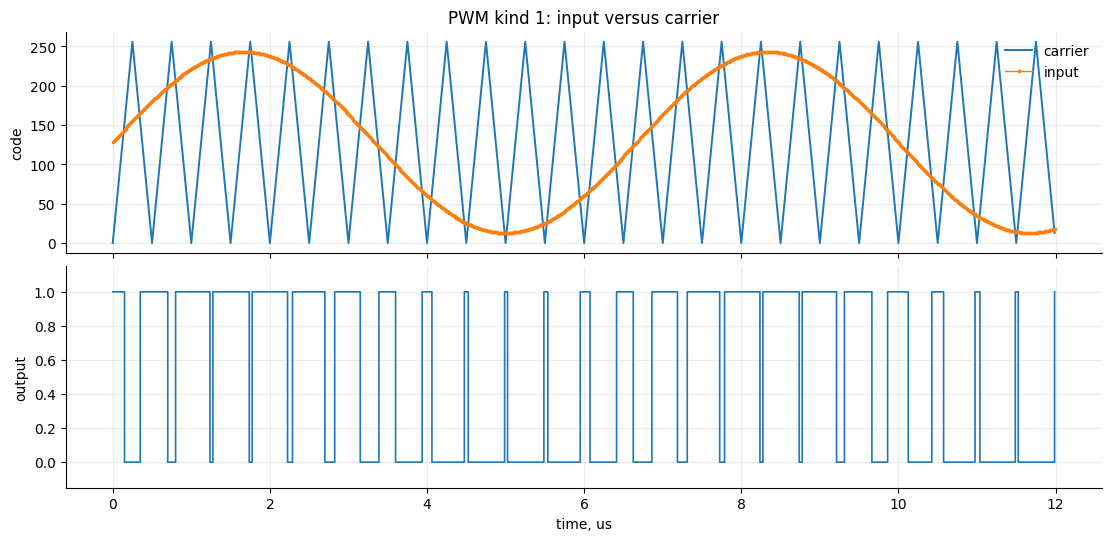

In [2]:
config = pl.PwmConfig(f_clk=80e6, f_pwm=2e6, resolution_bits=8)
n_periods = 24
n_clk = n_periods * config.period_samples

_, x_clk = pl.sine_samples(freq=150e3, sample_rate=config.f_clk, n_samples=n_clk, amplitude=0.9)
carrier = np.resize(pl.triangle_carrier(config.period_samples), n_clk)
y_pwm = pl.pwm_kind1(x_clk, config)

plot_pwm_carrier_output(
    x_clk,
    carrier,
    y_pwm,
    sample_rate=config.f_clk,
    input_scale=2**config.resolution_bits,
    title="PWM kind 1: input versus carrier",
);

## Спектр одного сигнала

Для PWM частота дискретизации спектра равна `config.f_clk`, потому что выходной поток формируется на частоте системного такта.

PWM kind 1
      0.1667 MHz  amplitude=0.421497
      2.0000 MHz  amplitude=0.355098
      3.8333 MHz  amplitude=0.132259
      4.1667 MHz  amplitude=0.113126
      2.3333 MHz  amplitude=0.108895


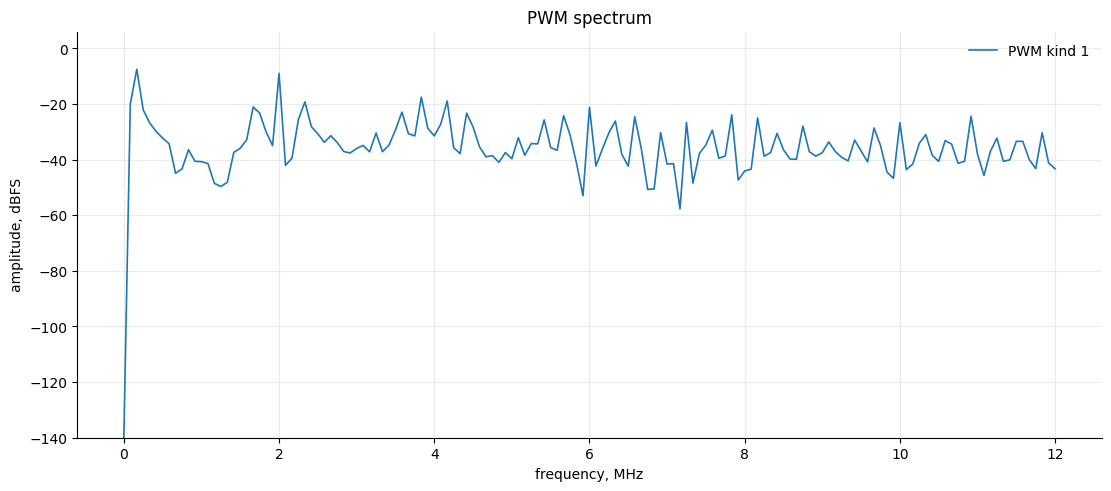

In [3]:
plot_spectra(
    {"PWM kind 1": y_pwm},
    sample_rate=config.f_clk,
    f_max=12e6,
    f_scale=1e6,
    f_unit="MHz",
    title="PWM spectrum",
);

print_peak_table(
    {"PWM kind 1": y_pwm},
    sample_rate=config.f_clk,
    f_min=1.0,
    f_max=12e6,
    f_scale=1e6,
    f_unit="MHz",
)

## Реконструкция через среднее

Это не аналоговый фильтр. Это быстрый численный индикатор: если усреднить PWM за период несущей, среднее должно повторять низкочастотную огибающую.

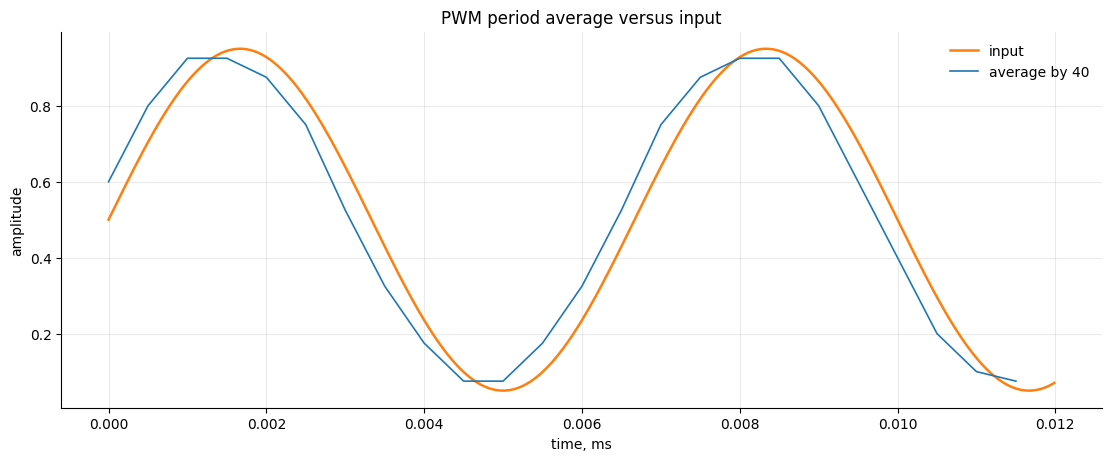

In [4]:
plot_moving_average_reconstruction(
    x_clk,
    y_pwm,
    input_sample_rate=config.f_clk,
    modulated_sample_rate=config.f_clk,
    average_factor=config.period_samples,
    title="PWM period average versus input",
);